In [2]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

<Axes: xlabel='job_title_short'>

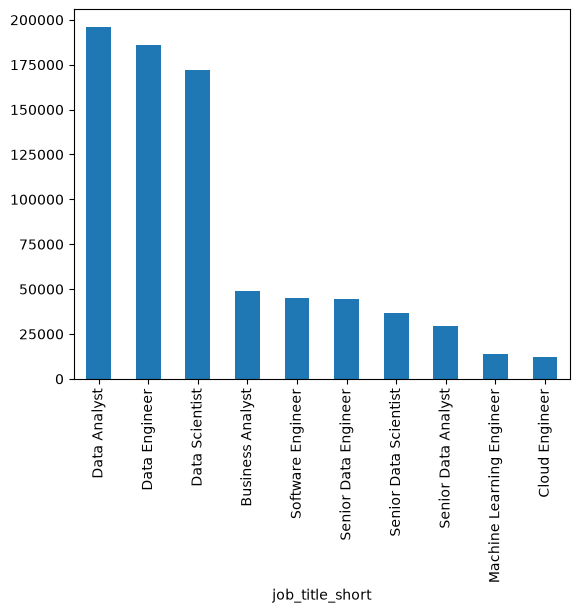

In [3]:
fig, ax = plt.subplots()

df['job_title_short'].value_counts().plot(kind='bar', ax=ax)

In [4]:
df['job_schedule_type'].value_counts().head(3)

job_schedule_type
Full-time     701727
Contractor     34793
Internship      8742
Name: count, dtype: int64

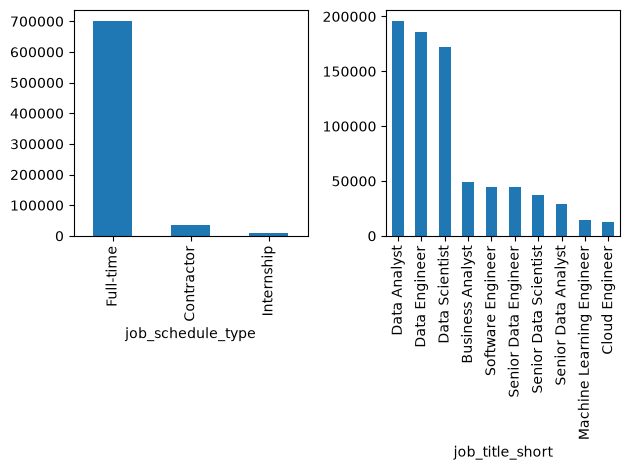

In [5]:
fig, ax = plt.subplots (1, 2)

df['job_title_short'].value_counts().plot(kind='bar', ax=ax[1])
df['job_schedule_type'].value_counts().head(3).plot(kind='bar', ax=ax[0])

fig.tight_layout()


In [6]:
df_skills = df.copy()
df_skills = df_skills.explode('job_skills')
skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skills_count = skills_count.reset_index(name='skill_count')
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)

df_skills_count

,job_skills,job_title_short,skill_count
1480,python,Data Scientist,113711
1822,sql,Data Engineer,113130
1479,python,Data Engineer,108022
1821,sql,Data Analyst,92428
1823,sql,Data Scientist,78982
...,...,...,...
2173,webex,Senior Data Scientist,1
293,codecommit,Business Analyst,1
2233,xamarin,Machine Learning Engineer,1
1087,mlr,Machine Learning Engineer,1


In [7]:
job_titles = ['Data Scientist', 'Data Engineer', 'Data Analyst']

C:\Users\Alfy\AppData\Local\Temp\ipykernel_18768\1042188047.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_plot = df_skills_count[df['job_title_short'] == job_title].head(5)
C:\Users\Alfy\AppData\Local\Temp\ipykernel_18768\1042188047.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_plot = df_skills_count[df['job_title_short'] == job_title].head(5)
C:\Users\Alfy\AppData\Local\Temp\ipykernel_18768\1042188047.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_plot = df_skills_count[df['job_title_short'] == job_title].head(5)


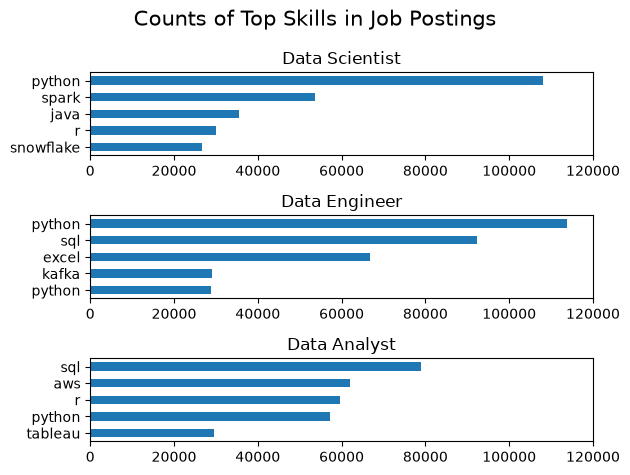

In [8]:
fig, ax = plt.subplots(3,1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df['job_title_short'] == job_title].head(5)
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], title=job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel("")
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0,120_000)

fig.suptitle('Counts of Top Skills in Job Postings', fontsize= 15)
fig.tight_layout()

# Problems

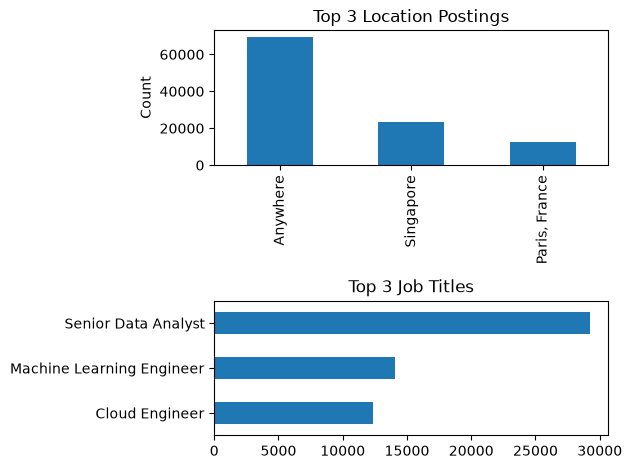

In [9]:
fig, ax = plt.subplots(2, 1)

df_top_3 = df['job_location'].value_counts().reset_index().head(3)

df_top_3.columns= ['job_location', 'location_count']

df_top_3.plot(kind='bar', x='job_location', y='location_count',ax=ax[0])
ax[0].set_title('Top 3 Location Postings')
ax[0].legend().set_visible(False)
ax[0].set_ylabel('Count')
ax[0].set_xlabel('')

df_top_3_jobs = df['job_title_short'].value_counts().sort_values(ascending=True).head(3).plot(kind='barh', ax=ax[1])
ax[1].set_title('Top 3 Job Titles')
ax[1].set_ylabel('')

fig.tight_layout()




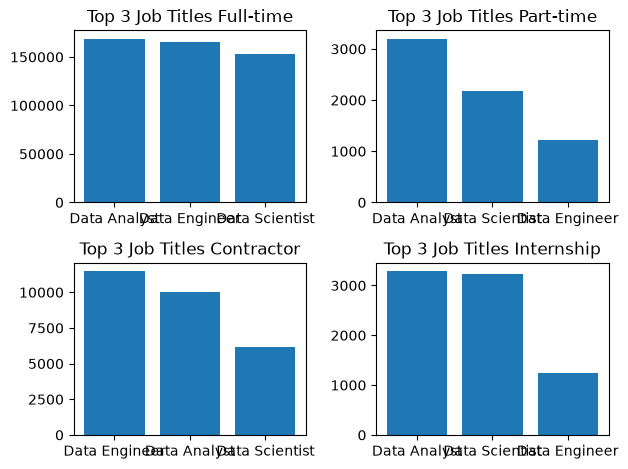

In [13]:
fig, ax = plt.subplots(2, 2)

schedules = ['Full-time', 'Part-time', 'Contractor', 'Internship']

for i, schedule in enumerate(schedules):
    df_schedule = df[df['job_schedule_type'] == schedule]
    job_titles = df_schedule['job_title_short'].value_counts().head(3)
    ax[i//2, i%2].bar(job_titles.index, job_titles.values)
    ax[i//2, i%2].set_title(f'Top 3 Job Titles {schedule}')

fig.tight_layout()
plt.show()



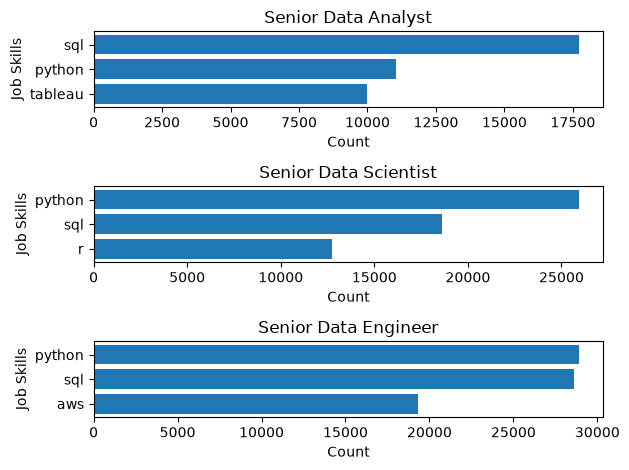

job_skills
python    28884
sql       28594
aws       19332
Name: count, dtype: int64

In [11]:
#Create a subplot with 3 rows and 1 column:
# In each subplot, plot a horizontal bar chart of the top 3 job skills by the number of job postings for each job title 
# (Senior Data Scientist, Senior Data Engineer, and Senior Data Analyst).
# Use fig.tight_layout() to adjust the spacing between subplots and invert_yaxis() to invert the y-axis in each subplot.

job_roles = ['Senior Data Analyst', 'Senior Data Scientist', 'Senior Data Engineer']
fig, ax = plt.subplots(len(job_roles), 1)
for i, role in enumerate(job_roles):
    top_3_skills = df_skills[df_skills['job_title_short'] == role]['job_skills'].explode('job_skills').value_counts().head(3)
    ax[i].barh(top_3_skills.index, top_3_skills.values)
    ax[i].set_title(role)
    ax[i].set_xlabel('Count')
    ax[i].set_ylabel('Job Skills')
    ax[i].invert_yaxis()
fig.tight_layout()
plt.show()

top_3_skills